In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Preprocessing the data
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X["sex"] = X["sex"].map({"male": 1, "female": 0})
X["smoker"] = X["smoker"].map({"yes": 1, "no": 0})
X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int)
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]
X.sample(10)

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,age_smoker,bmi_smoker
136,19,1,34.100,0,0,0,0,1,0,0.0
860,37,0,47.600,2,1,0,0,1,37,47.6
200,19,0,32.110,0,0,1,0,0,0,0.0
383,35,0,43.340,2,0,0,1,0,0,0.0
1168,32,1,35.200,2,0,0,0,1,0,0.0
1072,21,1,31.255,0,0,1,0,0,0,0.0
468,28,0,24.320,1,0,0,0,0,0,0.0
236,18,0,26.730,0,0,0,1,0,0,0.0
51,21,0,33.630,2,0,1,0,0,0,0.0
99,38,1,19.300,0,1,0,0,1,38,19.3


In [4]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Training the Ridge Regression model
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, y_train)

# Making predictions
y_pred = ridge_model.predict(X_test)

# Evaluating the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 20922417.541201826
R-squared: 0.8652329243520389


In [6]:
alpha_values = [0.001, 0.01, 0.1, 1, 5, 10, 15, 20, 25, 50]
mse_values = []
r2_values = []

for alpha in alpha_values:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mse_values.append(mse)
    r2_values.append(r2)
    print(f"Alpha: {alpha}, MSE: {mse}, R-squared: {r2}")

Alpha: 0.001, MSE: 20922417.541201826, R-squared: 0.8652329243520389
Alpha: 0.01, MSE: 20920713.858871143, R-squared: 0.8652438982409353
Alpha: 0.1, MSE: 20904627.387110725, R-squared: 0.8653475156528513
Alpha: 1, MSE: 20815963.249536037, R-squared: 0.8659186258752841
Alpha: 5, MSE: 20956035.723328464, R-squared: 0.8650163803467927
Alpha: 10, MSE: 21236465.194434453, R-squared: 0.8632100565951499
Alpha: 15, MSE: 21440667.140189, R-squared: 0.8618947354083526
Alpha: 20, MSE: 21587617.43298016, R-squared: 0.8609481879462308
Alpha: 25, MSE: 21697717.541633684, R-squared: 0.8602390027078358
Alpha: 50, MSE: 21998664.19164419, R-squared: 0.8583005221346374


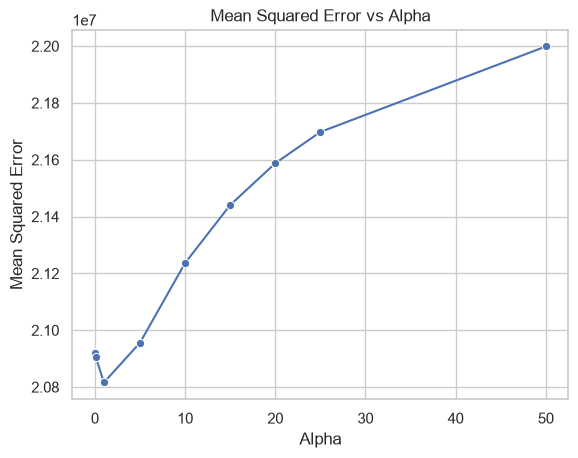

In [18]:
sns.set(style="whitegrid")
sns.lineplot(x=alpha_values, y=mse_values, marker="o")
plt.title("Mean Squared Error vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
plt.show()

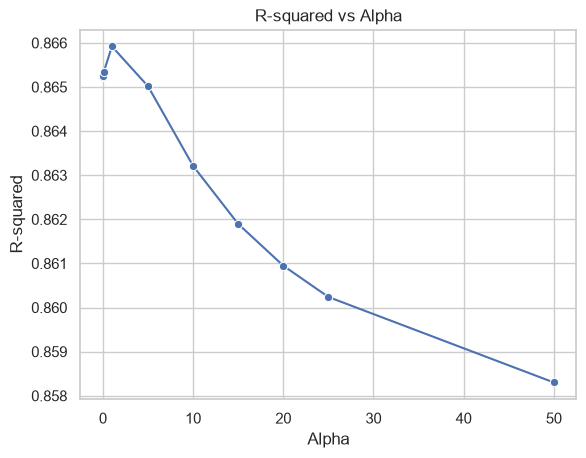

In [23]:
sns.lineplot(x=alpha_values, y=r2_values, marker="o")
plt.title("R-squared vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("R-squared")
plt.show()

In [17]:
ridge_cv_model = RidgeCV(
    alphas=alpha_values,
    cv=5,
)

ridge_cv_model.fit(X_train, y_train)

best_alpha = ridge_cv_model.alpha_
y_cv_pred = ridge_cv_model.predict(X_test)

mse_cv = mean_squared_error(y_test, y_cv_pred)
r2_cv = r2_score(y_test, y_cv_pred)
print(f"Best Alpha from RidgeCV: {best_alpha}")
print(f"Mean Squared Error (RidgeCV): {mse_cv}")
print(f"R-squared (RidgeCV): {r2_cv}")

Best Alpha from RidgeCV: 0.01
Mean Squared Error (RidgeCV): 20920713.858871143
R-squared (RidgeCV): 0.8652438982409353
